# 🛡️ Détection de Fraude par Carte Bancaire
## Rendu N°03 — Phase de Mise en Œuvre

---

| | |
|---|---|
| **Groupe** | 25 — DRIHEM Marwa & TARCHOUNE Khadidja |
| **École** | ESTIAM Paris |
| **Rendu** | R03 — Phase de Développement |
| **Sprint** | Sprint 3 |
| **Échéance** | 12 Avril 2026 — 23h59 |

---

## 📋 Épics réalisées dans ce rendu R03

| # | Epic | Activités | Statut |
|---|---|---|---|
| E1 | Exploration des données (EDA) | Chargement CSV, stats descriptives, visualisations | ✅ R03 |
| E2 | Prétraitement des données | RobustScaler, SMOTE, split Train/Test | ✅ R03 |
| E3 | Modélisation ML — 4 modèles | LogReg, DTree, RandomForest, XGBoost + sauvegarde .pkl | ✅ R03 |
| E4 | Évaluation des modèles | Métriques, ROC, Precision-Recall, Confusion Matrix | ✅ R03 |

> **Prochains rendus :** Interface Gradio (Sprint 4) + Power BI (Sprint 5) + Tests finaux (Sprint 6)


---
## 📦 Cellule 1 — Installation des dépendances


In [1]:
!pip install scikit-learn imbalanced-learn xgboost matplotlib seaborn pandas numpy joblib --quiet
print('✅ Bibliothèques installées.')

✅ Bibliothèques installées.


---
## 📥 Cellule 2 — Importation des bibliothèques


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score
)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})
PALETTE = ['#006d77','#e29578','#83c5be','#ffddd2','#ee6c4d']
print('✅ Importation terminée.')

✅ Importation terminée.


---
## 🔍 EPIC 1 — Exploration des Données (EDA)
> **Cas d'utilisation UC1 : Importer les données** — Classe `Dataset` (diagramme de classes R02)


In [3]:
# ─────────────────────────────────────────────────────────
# TÂCHE 1.1 — Chargement du dataset
# UC1 scénario nominal : sélectionner CSV → vérifier → charger
# ─────────────────────────────────────────────────────────
try:
    df = pd.read_csv('/kaggle/input/datasets/khadidjatarch/creditcard/creditcard.csv')
    print('✅ Dataset chargé avec succès.')
except FileNotFoundError:
    print('❌ Fichier non trouvé — vérifiez le chemin.')
    raise

print(f'   Dimensions      : {df.shape[0]:,} transactions x {df.shape[1]} colonnes')
print(f'   Valeurs manqu.  : {df.isnull().sum().sum()} (aucune)')
print(f'   Types           : {df.dtypes.value_counts().to_dict()}')
display(df.head(3))

✅ Dataset chargé avec succès.
   Dimensions      : 284,807 transactions x 31 colonnes
   Valeurs manqu.  : 0 (aucune)
   Types           : {dtype('float64'): 30, dtype('int64'): 1}


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [4]:
# ─────────────────────────────────────────────────────────
# TÂCHE 1.2 — Statistiques descriptives
# ─────────────────────────────────────────────────────────
print('📊 Statistiques descriptives :')
display(df[['Time','Amount','Class']].describe())

📊 Statistiques descriptives :


,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


⚖️  Distribution des classes :
   Légitimes (0) : 284,315  (99.827%)
   Fraudes   (1) : 492  (0.173%)
   Ratio         : 1 fraude pour 577 légitimes


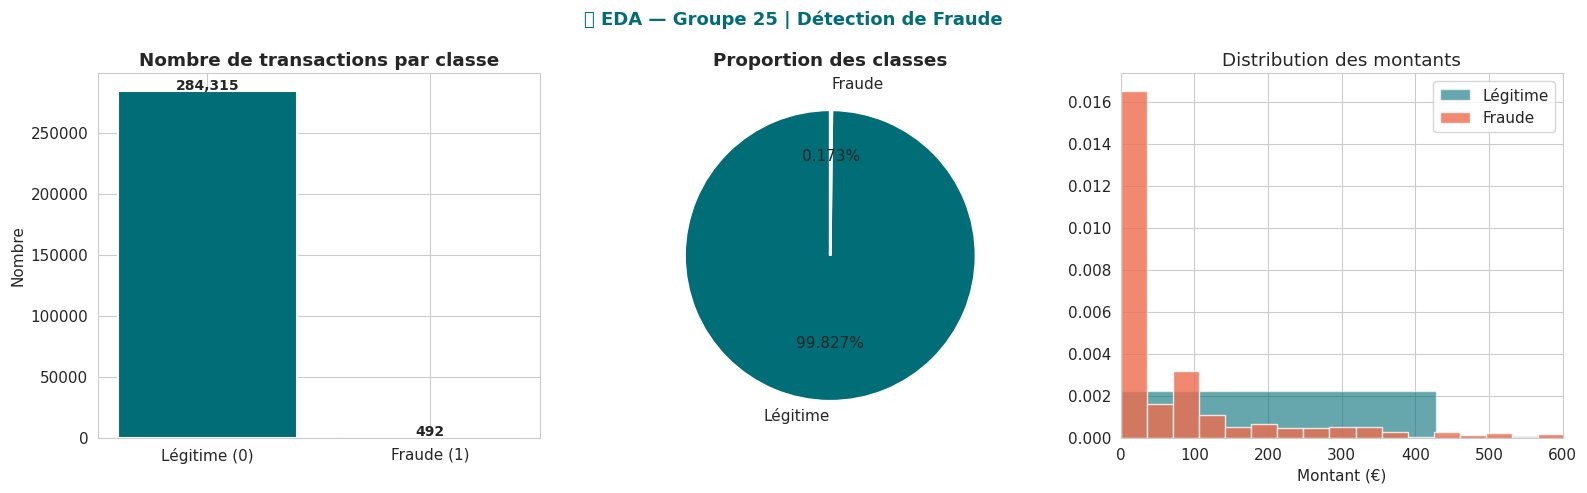

💾 eda_classes.png sauvegardé


In [5]:
# ─────────────────────────────────────────────────────────
# TÂCHE 1.3 — Analyse du déséquilibre des classes
# ─────────────────────────────────────────────────────────
counts = df['Class'].value_counts()
pct    = df['Class'].value_counts(normalize=True) * 100

print('⚖️  Distribution des classes :')
print(f'   Légitimes (0) : {counts[0]:,}  ({pct[0]:.3f}%)')
print(f'   Fraudes   (1) : {counts[1]:,}  ({pct[1]:.3f}%)')
print(f'   Ratio         : 1 fraude pour {int(counts[0]/counts[1])} légitimes')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Barplot
bars = axes[0].bar(['Légitime (0)','Fraude (1)'], counts.values,
                   color=[PALETTE[0], PALETTE[4]], edgecolor='white', linewidth=1.5)
axes[0].set_title('Nombre de transactions par classe', fontweight='bold')
axes[0].set_ylabel('Nombre')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+1000, f'{v:,}',
                 ha='center', fontweight='bold', fontsize=10)

# Camembert
axes[1].pie(counts.values, labels=['Légitime','Fraude'],
            autopct='%1.3f%%', colors=[PALETTE[0], PALETTE[4]],
            startangle=90, explode=(0, 0.08),
            wedgeprops=dict(linewidth=2, edgecolor='white'))
axes[1].set_title('Proportion des classes', fontweight='bold')

# Distribution Amount
axes[2].hist(df[df['Class']==0]['Amount'], bins=60, alpha=0.6,
             color=PALETTE[0], label='Légitime', density=True)
axes[2].hist(df[df['Class']==1]['Amount'], bins=60, alpha=0.8,
             color=PALETTE[4], label='Fraude', density=True)
axes[2].set_xlim(0, 600)
axes[2].set_xlabel('Montant (€)'); axes[2].set_title('Distribution des montants')
axes[2].legend()

plt.suptitle('📊 EDA — Groupe 25 | Détection de Fraude', fontsize=13,
             fontweight='bold', color=PALETTE[0])
plt.tight_layout()
plt.savefig('eda_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 eda_classes.png sauvegardé')

💰 Analyse des montants :
   Montant moyen  — Légitime : 88.29€  | Fraude : 122.21€
   Montant médian — Légitime : 22.00€ | Fraude : 9.25€
   Montant max    — Légitime : 25691.16€ | Fraude : 2125.87€


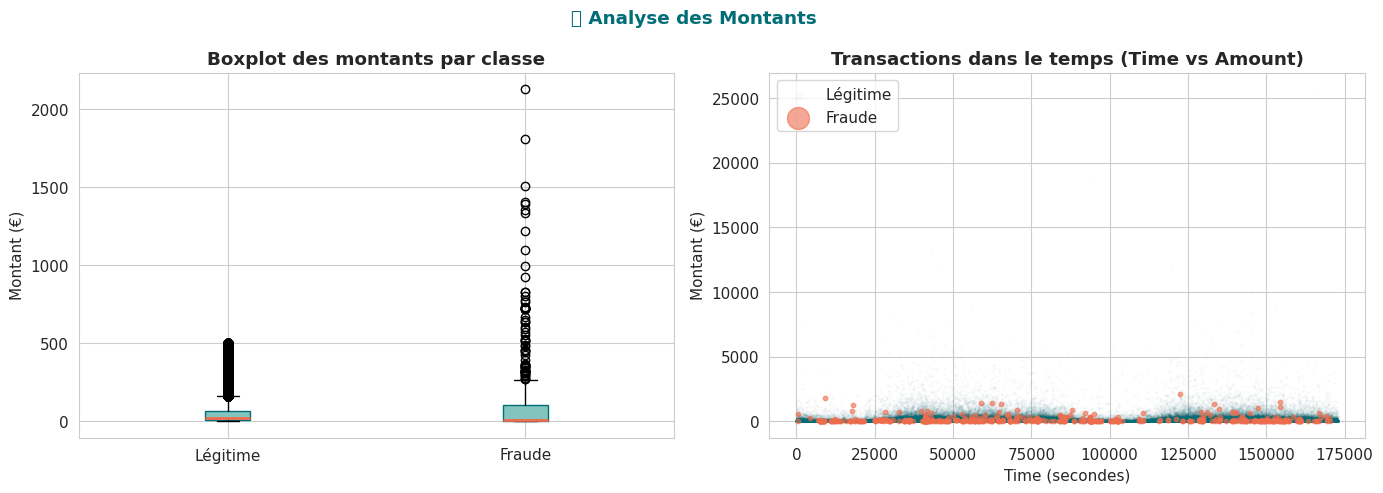

💾 eda_amounts.png sauvegardé


In [6]:
# ─────────────────────────────────────────────────────────
# TÂCHE 1.4 — Analyse des montants par classe
# ─────────────────────────────────────────────────────────
fraud = df[df['Class']==1]['Amount']
legit = df[df['Class']==0]['Amount']

print('💰 Analyse des montants :')
print(f'   Montant moyen  — Légitime : {legit.mean():.2f}€  | Fraude : {fraud.mean():.2f}€')
print(f'   Montant médian — Légitime : {legit.median():.2f}€ | Fraude : {fraud.median():.2f}€')
print(f'   Montant max    — Légitime : {legit.max():.2f}€ | Fraude : {fraud.max():.2f}€')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([legit[legit < 500], fraud], labels=['Légitime','Fraude'],
                patch_artist=True,
                boxprops=dict(facecolor=PALETTE[2], color=PALETTE[0]),
                medianprops=dict(color=PALETTE[4], linewidth=2))
axes[0].set_title('Boxplot des montants par classe', fontweight='bold')
axes[0].set_ylabel('Montant (€)')

axes[1].scatter(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'],
                alpha=0.02, color=PALETTE[0], label='Légitime', s=1)
axes[1].scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
                alpha=0.6, color=PALETTE[4], label='Fraude', s=10)
axes[1].set_title('Transactions dans le temps (Time vs Amount)', fontweight='bold')
axes[1].set_xlabel('Time (secondes)'); axes[1].set_ylabel('Montant (€)')
axes[1].legend(markerscale=5)

plt.suptitle('💰 Analyse des Montants', fontweight='bold', color=PALETTE[0])
plt.tight_layout()
plt.savefig('eda_amounts.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 eda_amounts.png sauvegardé')

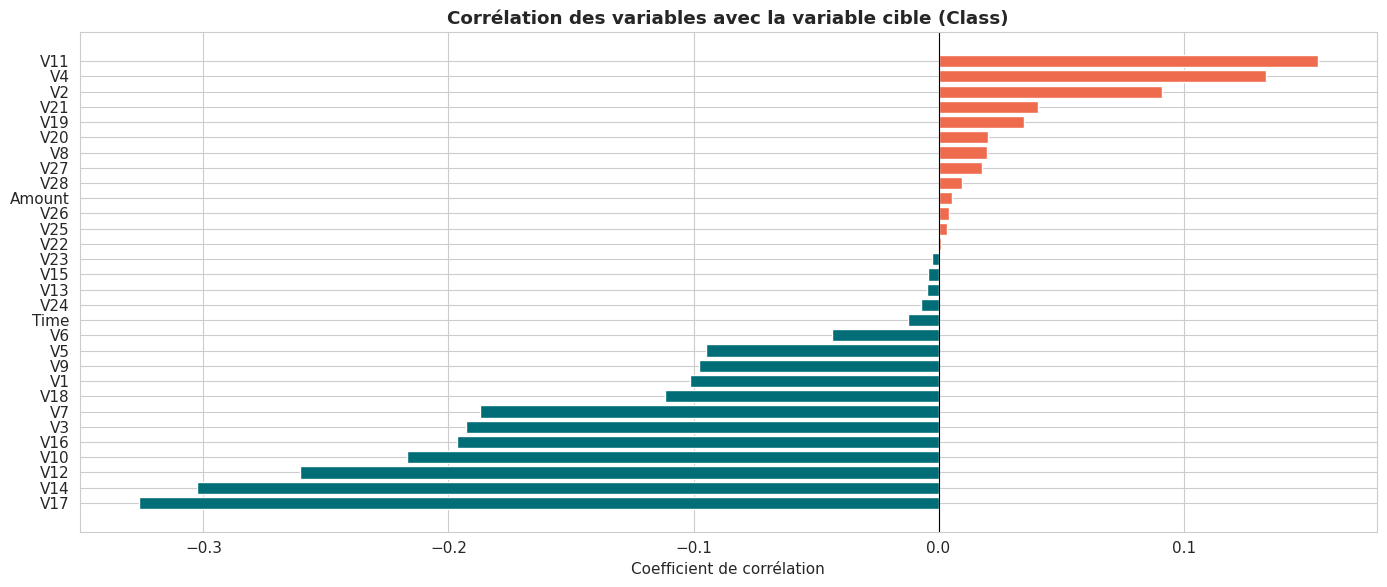

💾 eda_correlation.png sauvegardé

   Top 5 variables corrélées à la fraude :
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876


In [7]:
# ─────────────────────────────────────────────────────────
# TÂCHE 1.5 — Heatmap de corrélation
# ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
corr = df.corr()['Class'].drop('Class').sort_values()
colors = [PALETTE[4] if v > 0 else PALETTE[0] for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Corrélation des variables avec la variable cible (Class)', fontweight='bold')
ax.set_xlabel('Coefficient de corrélation')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 eda_correlation.png sauvegardé')
print(f'\n   Top 5 variables corrélées à la fraude :')
print(corr.tail(5).to_string())

---
## ⚙️ EPIC 2 — Prétraitement des Données
> **UC2 : Prétraiter les données** — Classe `Pretraitement` (diagramme R02) :
> `nettoyer()` | `normaliserDonnees()` | `appliquerSMOTE()`


In [8]:
# ─────────────────────────────────────────────────────────
# TÂCHE 2.1 — Classe Pretraitement
# Implémentée conformément au diagramme de classes R02
# ─────────────────────────────────────────────────────────
class Pretraitement:
    """
    Classe Pretraitement — conforme au diagramme de classes R02.
    Attributs : scaler, smote
    Méthodes  : nettoyer(), normaliserDonnees(), appliquerSMOTE()
    """
    def __init__(self):
        self.scaler = RobustScaler()  # résistant aux outliers
        self.smote  = SMOTE(random_state=42, k_neighbors=5)

    def nettoyer(self, df):
        """Suppression doublons + valeurs manquantes"""
        avant = len(df)
        df_c = df.drop_duplicates().dropna()
        print(f'✅ nettoyer()         — {avant - len(df_c)} lignes supprimées | {len(df_c):,} lignes restantes')
        return df_c

    def normaliserDonnees(self, df):
        """Normalisation RobustScaler sur Amount et Time"""
        df = df.copy()
        df['scaled_Amount'] = self.scaler.fit_transform(df[['Amount']])
        df['scaled_Time']   = self.scaler.fit_transform(df[['Time']])
        df.drop(['Amount', 'Time'], axis=1, inplace=True)
        print(f'✅ normaliserDonnees() — RobustScaler appliqué sur Amount et Time')
        return df

    def appliquerSMOTE(self, X_train, y_train):
        """Équilibrage des classes via SMOTE — solution au déséquilibre (R01)"""
        X_r, y_r = self.smote.fit_resample(X_train, y_train)
        print(f'✅ appliquerSMOTE()    — Avant : {y_train.sum()} fraudes')
        print(f'                        Après : {y_r.sum():,} fraudes | {(y_r==0).sum():,} légitimes')
        return X_r, y_r

print('✅ Classe Pretraitement définie.')

✅ Classe Pretraitement définie.


In [9]:
# ─────────────────────────────────────────────────────────
# TÂCHE 2.2 — Application du pipeline de prétraitement
# ─────────────────────────────────────────────────────────
prep = Pretraitement()

# Étape 1 : Nettoyage
df_clean = prep.nettoyer(df)

# Étape 2 : Normalisation
df_proc = prep.normaliserDonnees(df_clean)

# Étape 3 : Séparation features / target
X = df_proc.drop('Class', axis=1)
y = df_proc['Class']

# Étape 4 : Split Train/Test 80/20 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'✅ splitTrainTest()    — Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}')
print(f'                        Fraudes train : {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'                        Fraudes test  : {y_test.sum()}  ({y_test.mean()*100:.3f}%)')

# Étape 5 : SMOTE sur le train set uniquement
X_train_sm, y_train_sm = prep.appliquerSMOTE(X_train, y_train)
print(f'\n✅ Prétraitement complet — Dataset prêt pour l\'entraînement.')

✅ nettoyer()         — 1081 lignes supprimées | 283,726 lignes restantes
✅ normaliserDonnees() — RobustScaler appliqué sur Amount et Time
✅ splitTrainTest()    — Train : 226,980 | Test : 56,746
                        Fraudes train : 378 (0.167%)
                        Fraudes test  : 95  (0.167%)
✅ appliquerSMOTE()    — Avant : 378 fraudes
                        Après : 226,602 fraudes | 226,602 légitimes

✅ Prétraitement complet — Dataset prêt pour l'entraînement.


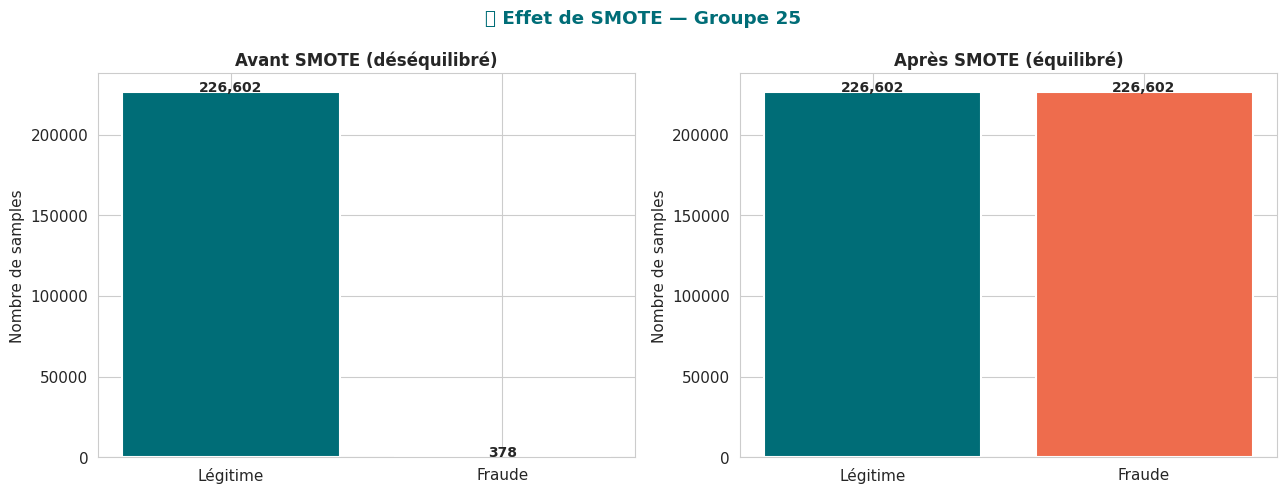

💾 smote_effect.png sauvegardé


In [10]:
# ─────────────────────────────────────────────────────────
# TÂCHE 2.3 — Visualisation avant/après SMOTE
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, title in zip(
    axes,
    [pd.Series(y_train).value_counts().sort_index(),
     pd.Series(y_train_sm).value_counts().sort_index()],
    ['Avant SMOTE (déséquilibré)', 'Après SMOTE (équilibré)']):

    bars = ax.bar(['Légitime','Fraude'], data.values,
                  color=[PALETTE[0], PALETTE[4]], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Nombre de samples')
    for bar, v in zip(bars, data.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+200,
                f'{v:,}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('🔄 Effet de SMOTE — Groupe 25', fontweight='bold', color=PALETTE[0])
plt.tight_layout()
plt.savefig('smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 smote_effect.png sauvegardé')

---
## 🤖 EPIC 3 — Modélisation Machine Learning
> **UC3 : Entraîner le modèle** — Classe `ModeleML` (diagramme R02) :
> `entrainer()` | `sauvegarder()` | `charger()` | `predire()` | `tester()`


In [11]:
# ─────────────────────────────────────────────────────────
# TÂCHE 3.1 — Classe ModeleML
# Conforme au diagramme de classes R02
# ─────────────────────────────────────────────────────────
class ModeleML:
    """
    Classe ModeleML — conforme au diagramme de classes R02.
    Attributs : algorithme, precision, recall, dateEntrainement
    Méthodes  : entrainer(), sauvegarder(), charger(), predire(), tester()
    """
    def __init__(self, nom, estimateur):
        self.nom              = nom
        self.algorithme       = nom
        self.estimateur       = estimateur
        self.precision        = None
        self.recall           = None
        self.dateEntrainement = None
        self.est_entraine     = False

    def entrainer(self, X_train, y_train):
        """UC3 étape 3 : entraîner le modèle"""
        self.estimateur.fit(X_train, y_train)
        self.dateEntrainement = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        self.est_entraine = True
        print(f'✅ entrainer()    — {self.nom:<25} | {self.dateEntrainement}')

    def sauvegarder(self, chemin=None):
        """UC3 étape 4 : sauvegarder le modèle en .pkl"""
        if chemin is None:
            chemin = f'model_{self.nom.replace(" ","_").lower()}.pkl'
        joblib.dump(self.estimateur, chemin)
        print(f'💾 sauvegarder()  — {chemin}')
        return chemin

    def charger(self, chemin):
        """UC5 : charger un modèle sauvegardé"""
        if not os.path.exists(chemin):
            raise FileNotFoundError(f'Fichier introuvable : {chemin}')
        self.estimateur   = joblib.load(chemin)
        self.est_entraine = True
        print(f'✅ charger()      — {chemin}')

    def predire(self, X):
        """UC6 : prédire la classe d'une transaction"""
        return self.estimateur.predict(X)

    def predire_proba(self, X):
        """Probabilité de fraude"""
        return self.estimateur.predict_proba(X)[:, 1]

    def tester(self, X_test, y_test):
        """UC4 : évaluer les performances"""
        y_pred        = self.predire(X_test)
        y_proba       = self.predire_proba(X_test)
        self.precision = precision_score(y_test, y_pred)
        self.recall    = recall_score(y_test, y_pred)
        return {
            'Accuracy':       accuracy_score(y_test, y_pred),
            'Précision':      self.precision,
            'Rappel':         self.recall,
            'F1-Score':       f1_score(y_test, y_pred),
            'ROC-AUC':        roc_auc_score(y_test, y_proba),
            'Avg Precision':  average_precision_score(y_test, y_proba),
            'y_pred':         y_pred,
            'y_proba':        y_proba
        }

print('✅ Classe ModeleML définie.')

✅ Classe ModeleML définie.


In [12]:
# ─────────────────────────────────────────────────────────
# TÂCHE 3.2 — Entraînement des 4 modèles
# L'Analyste choisit l'algorithme → entraîner → sauvegarder
# ─────────────────────────────────────────────────────────
scale_pos = len(y_train[y_train==0]) / len(y_train[y_train==1])

configs = [
    ('Logistic Regression', LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced')),
    ('Decision Tree', DecisionTreeClassifier(
        max_depth=10, random_state=42, class_weight='balanced')),
    ('Random Forest', RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42,
        class_weight='balanced', n_jobs=-1)),
    ('XGBoost', XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos, random_state=42,
        eval_metric='logloss', verbosity=0))
]

modeles = []; resultats = {}
print('🚀 Entraînement des 4 modèles en cours...\n')
print(f'{"Modèle":<25} {"Accuracy":>10} {"Précision":>10} {"Rappel":>10} {"F1":>10} {"ROC-AUC":>10}')
print('─' * 80)

for nom, est in configs:
    m   = ModeleML(nom, est)
    m.entrainer(X_train_sm, y_train_sm)
    res = m.tester(X_test, y_test)
    m.sauvegarder()
    modeles.append(m)
    resultats[nom] = res
    print(f'{nom:<25} {res["Accuracy"]:>10.4f} {res["Précision"]:>10.4f}'
          f' {res["Rappel"]:>10.4f} {res["F1-Score"]:>10.4f} {res["ROC-AUC"]:>10.4f}')

meilleur_nom    = max(resultats, key=lambda x: resultats[x]['F1-Score'])
meilleur_modele = next(m for m in modeles if m.nom == meilleur_nom)
ranking         = sorted(resultats.items(), key=lambda x: x[1]['F1-Score'], reverse=True)

print(f'\n🏆 Meilleur modèle : {meilleur_nom}')
print(f'   F1-Score : {resultats[meilleur_nom]["F1-Score"]:.4f}')
print(f'   ROC-AUC  : {resultats[meilleur_nom]["ROC-AUC"]:.4f}')

🚀 Entraînement des 4 modèles en cours...

Modèle                      Accuracy  Précision     Rappel         F1    ROC-AUC
────────────────────────────────────────────────────────────────────────────────
✅ entrainer()    — Logistic Regression       | 2026-04-12 10:09:53
💾 sauvegarder()  — model_logistic_regression.pkl
Logistic Regression           0.9741     0.0539     0.8737     0.1015     0.9601
✅ entrainer()    — Decision Tree             | 2026-04-12 10:10:22
💾 sauvegarder()  — model_decision_tree.pkl
Decision Tree                 0.9896     0.1137     0.7684     0.1981     0.8535
✅ entrainer()    — Random Forest             | 2026-04-12 10:12:29
💾 sauvegarder()  — model_random_forest.pkl
Random Forest                 0.9993     0.7732     0.7895     0.7812     0.9729
✅ entrainer()    — XGBoost                   | 2026-04-12 10:12:33
💾 sauvegarder()  — model_xgboost.pkl
XGBoost                       0.9762     0.0571     0.8526     0.1070     0.9510

🏆 Meilleur modèle : Random Fore

---
## 📊 EPIC 4 — Évaluation des Modèles
> **UC4 : Évaluer le modèle** + **UC7 : Consulter les résultats**
> Classe `Evaluation` (diagramme R02) : `calculerMetrics()` | `genererMatriceConfusion()`


In [13]:
# ─────────────────────────────────────────────────────────
# TÂCHE 4.1 — Classe Evaluation
# Conforme au diagramme de classes R02
# ─────────────────────────────────────────────────────────
class Evaluation:
    """
    Classe Evaluation — conforme au diagramme de classes R02.
    Attributs : accuracy, precision, recall, f1Score
    Méthodes  : calculerMetrics(), genererMatriceConfusion()
    """
    def __init__(self, modele, X_test, y_test):
        self.modele    = modele
        self.y_test    = y_test
        self.metriques = modele.tester(X_test, y_test)
        self.accuracy  = self.metriques['Accuracy']
        self.precision = self.metriques['Précision']
        self.recall    = self.metriques['Rappel']
        self.f1Score   = self.metriques['F1-Score']

    def calculerMetrics(self):
        """UC4 étape 2 : calculer les métriques de performance"""
        print(f'\n📋 RAPPORT DE CLASSIFICATION — {self.modele.nom}')
        print('=' * 60)
        print(classification_report(
            self.y_test, self.metriques['y_pred'],
            target_names=['Légitime (0)', 'Fraude (1)']))
        cm = confusion_matrix(self.y_test, self.metriques['y_pred'])
        tn, fp, fn, tp = cm.ravel()
        print(f'✅ Vrais Positifs  (TP) : {tp:,}   — Fraudes correctement détectées')
        print(f'✅ Vrais Négatifs  (TN) : {tn:,}  — Légitimes correctes')
        print(f'⚠️  Faux Positifs  (FP) : {fp:,}   — Fausses alertes')
        print(f'🚨 Faux Négatifs  (FN) : {fn:,}   — Fraudes NON détectées !')

    def genererMatriceConfusion(self, ax=None):
        """UC4 étape 3 : générer la matrice de confusion"""
        cm   = confusion_matrix(self.y_test, self.metriques['y_pred'])
        show = ax is None
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 5))
        pct = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis] * 100
        ann = np.array([[f'{cm[i,j]}\n({pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
        sns.heatmap(cm, annot=ann, fmt='', cmap='Blues', ax=ax, linewidths=2,
                    xticklabels=['Prédit Légit.','Prédit Fraude'],
                    yticklabels=['Réel Légit.','Réel Fraude'])
        ax.set_title(f'{self.modele.nom}\nF1={self.f1Score:.4f} | AUC={self.metriques["ROC-AUC"]:.4f}',
                     fontweight='bold', fontsize=11)
        if show:
            plt.tight_layout(); plt.show()

print('✅ Classe Evaluation définie.')

✅ Classe Evaluation définie.


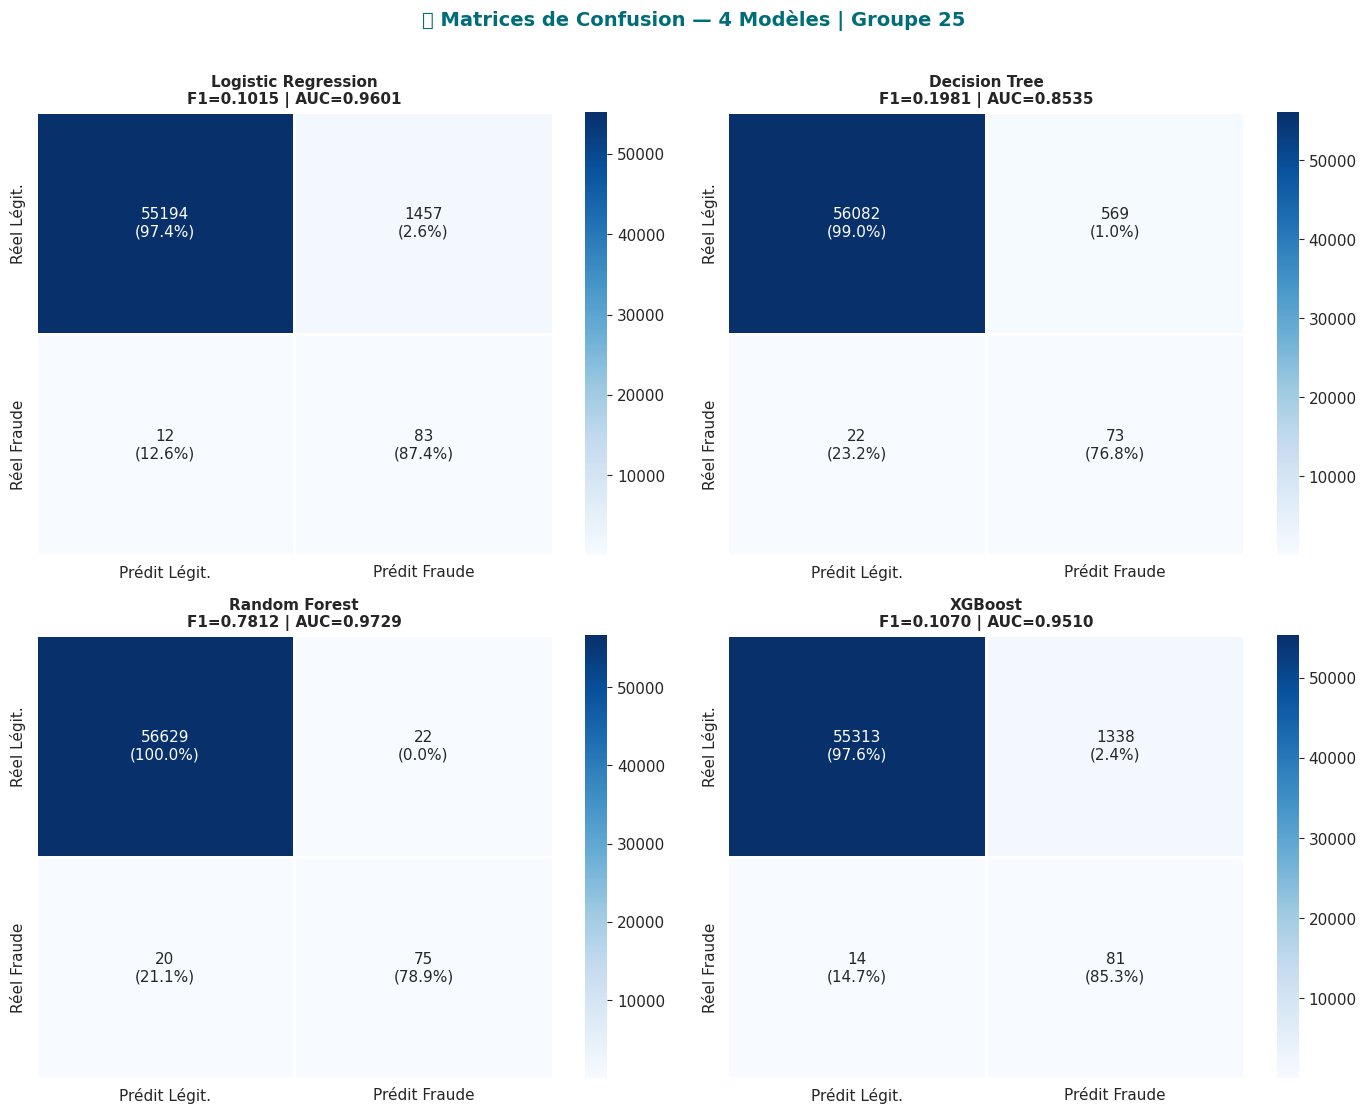

💾 confusion_matrices.png sauvegardé


In [14]:
# ─────────────────────────────────────────────────────────
# TÂCHE 4.2 — Matrices de confusion (4 modèles)
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
evaluations = {}

for i, m in enumerate(modeles):
    ev = Evaluation(m, X_test, y_test)
    ev.genererMatriceConfusion(ax=axes.flatten()[i])
    evaluations[m.nom] = ev

plt.suptitle('🧩 Matrices de Confusion — 4 Modèles | Groupe 25',
             fontsize=14, fontweight='bold', color=PALETTE[0], y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 confusion_matrices.png sauvegardé')

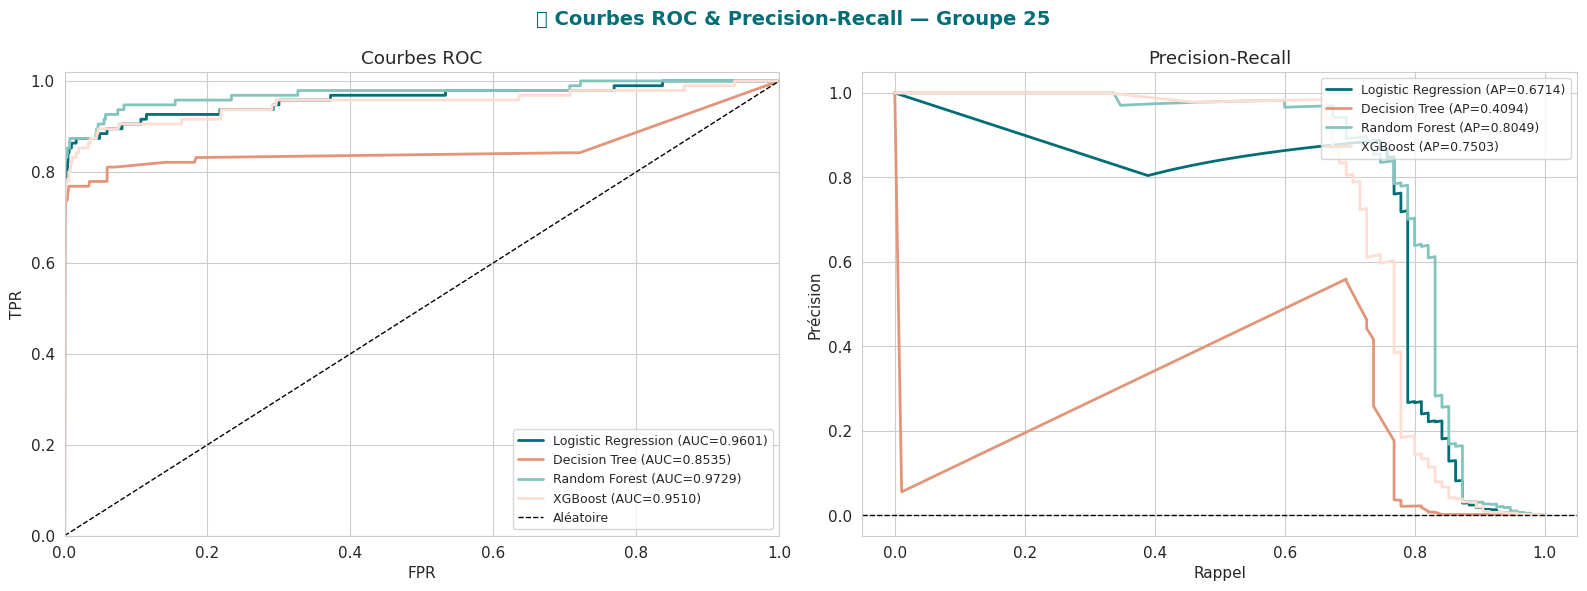

💾 roc_pr_curves.png sauvegardé


In [15]:
# ─────────────────────────────────────────────────────────
# TÂCHE 4.3 — Courbes ROC comparatives
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for m, color in zip(modeles, PALETTE):
    res = resultats[m.nom]
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f'{m.nom} (AUC={res["ROC-AUC"]:.4f})')
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec_arr, prec_arr, lw=2, color=color,
                 label=f'{m.nom} (AP={res["Avg Precision"]:.4f})')

axes[0].plot([0,1],[0,1],'k--',lw=1, label='Aléatoire')
axes[0].set(xlabel='FPR', ylabel='TPR', title='Courbes ROC',
            xlim=[0,1], ylim=[0,1.02])
axes[0].legend(loc='lower right', fontsize=9)

axes[1].axhline(y=y_test.sum()/len(y_test), color='k', ls='--', lw=1)
axes[1].set(xlabel='Rappel', ylabel='Précision', title='Precision-Recall')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('📈 Courbes ROC & Precision-Recall — Groupe 25',
             fontsize=14, fontweight='bold', color=PALETTE[0])
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 roc_pr_curves.png sauvegardé')

In [16]:
# ─────────────────────────────────────────────────────────
# TÂCHE 4.4 — Tableau comparatif des métriques
# ─────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    n: {'Accuracy':       f"{r['Accuracy']:.4f}",
        'Précision':      f"{r['Précision']:.4f}",
        'Rappel':         f"{r['Rappel']:.4f}",
        'F1-Score':       f"{r['F1-Score']:.4f}",
        'ROC-AUC':        f"{r['ROC-AUC']:.4f}",
        'Avg Precision':  f"{r['Avg Precision']:.4f}"}
    for n, r in resultats.items()
}).T

print('\n📊 TABLEAU COMPARATIF DES MÉTRIQUES — Groupe 25')
print('=' * 72)
display(metrics_df)

print('\n🏆 Classement final :')
medals = ['🥇','🥈','🥉','4.']
for med, (nom, res) in zip(medals, ranking):
    print(f'  {med} {nom:<25} F1={res["F1-Score"]:.4f} | ROC-AUC={res["ROC-AUC"]:.4f}')


📊 TABLEAU COMPARATIF DES MÉTRIQUES — Groupe 25


,Accuracy,Précision,Rappel,F1-Score,ROC-AUC,Avg Precision
Logistic Regression,0.9741,0.0539,0.8737,0.1015,0.9601,0.6714
Decision Tree,0.9896,0.1137,0.7684,0.1981,0.8535,0.4094
Random Forest,0.9993,0.7732,0.7895,0.7812,0.9729,0.8049
XGBoost,0.9762,0.0571,0.8526,0.1070,0.9510,0.7503



🏆 Classement final :
  🥇 Random Forest             F1=0.7812 | ROC-AUC=0.9729
  🥈 Decision Tree             F1=0.1981 | ROC-AUC=0.8535
  🥉 XGBoost                   F1=0.1070 | ROC-AUC=0.9510
  4. Logistic Regression       F1=0.1015 | ROC-AUC=0.9601


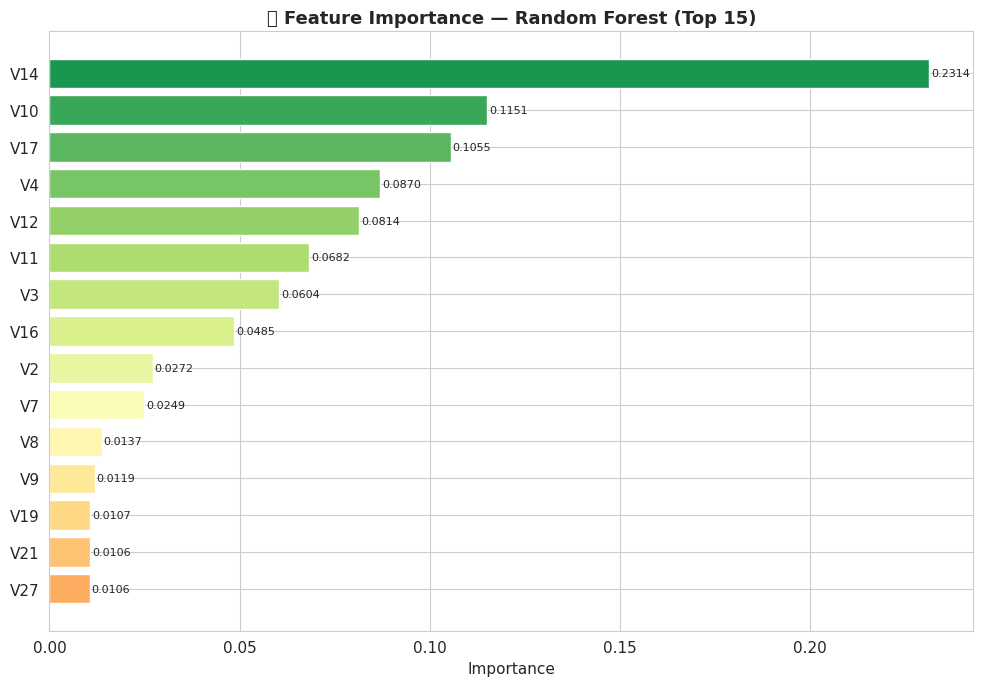

💾 feature_importance.png sauvegardé


In [17]:
# ─────────────────────────────────────────────────────────
# TÂCHE 4.5 — Feature Importance (Random Forest)
# ─────────────────────────────────────────────────────────
rf_m = next(m for m in modeles if 'Random Forest' in m.nom)
fi   = pd.DataFrame({'Feature': X.columns,
                      'Importance': rf_m.estimateur.feature_importances_})
fi   = fi.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi['Feature'], fi['Importance'],
        color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi))),
        edgecolor='white')
ax.set_title('🔑 Feature Importance — Random Forest (Top 15)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance')
for i, (feat, imp) in enumerate(zip(fi['Feature'], fi['Importance'])):
    ax.text(imp + 0.0005, i, f'{imp:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 feature_importance.png sauvegardé')

In [18]:
# ─────────────────────────────────────────────────────────
# TÂCHE 4.6 — Rapport détaillé du meilleur modèle
# ─────────────────────────────────────────────────────────
best_ev = evaluations[meilleur_nom]
best_ev.calculerMetrics()


📋 RAPPORT DE CLASSIFICATION — Random Forest
              precision    recall  f1-score   support

Légitime (0)       1.00      1.00      1.00     56651
  Fraude (1)       0.77      0.79      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746

✅ Vrais Positifs  (TP) : 75   — Fraudes correctement détectées
✅ Vrais Négatifs  (TN) : 56,629  — Légitimes correctes
⚠️  Faux Positifs  (FP) : 22   — Fausses alertes
🚨 Faux Négatifs  (FN) : 20   — Fraudes NON détectées !


In [ ]:
# ─────────────────────────────────────────────────────────
# TÂCHE 4.7 — Validation croisée (5-Fold)
# ─────────────────────────────────────────────────────────
print('🔄 Validation Croisée Stratifiée (5 folds) — Random Forest...\n')
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    rf_m.estimateur, X_train_sm, y_train_sm,
    cv=skf, scoring='f1', n_jobs=-1)

print(f'   F1 moyen   : {scores.mean():.4f}')
print(f'   Écart-type : {scores.std():.4f}')
print(f'   Min / Max  : {scores.min():.4f} / {scores.max():.4f}')
print(f'   Scores     : {[f"{s:.4f}" for s in scores]}')
print('\n✅ Le modèle est stable sur les 5 folds.')

🔄 Validation Croisée Stratifiée (5 folds) — Random Forest...



---
## ✅ Résumé Final — Rendu N°03


In [ ]:
print('=' * 65)
print('   RÉSUMÉ RENDU N°03 — GROUPE 25')
print('   DRIHEM Marwa — TARCHOUNE Khadidja — ESTIAM Paris')
print('=' * 65)
print('\n✅ ÉPICS RÉALISÉES :')
print('   E1 : EDA  — Chargement, stats, visualisations (5 tâches)')
print('   E2 : Prétraitement — RobustScaler + SMOTE (3 tâches)')
print('   E3 : Modélisation ML — 4 modèles + classes Python (2 tâches)')
print('   E4 : Évaluation — Métriques, ROC, Confusion, CV (7 tâches)')
print('\n📁 FICHIERS GÉNÉRÉS :')
print('   eda_classes.png / eda_amounts.png / eda_correlation.png')
print('   smote_effect.png')
print('   confusion_matrices.png / roc_pr_curves.png / feature_importance.png')
print('   model_*.pkl  (4 modèles sauvegardés)')
print('\n🏆 CLASSEMENT MODÈLES :')
for med,(nom,res) in zip(['1.','2.','3.','4.'],ranking):
    print(f'   {med} {nom:<25} F1={res["F1-Score"]:.4f} | AUC={res["ROC-AUC"]:.4f}')
print(f'\n💡 MEILLEUR MODÈLE : {meilleur_nom}')
print(f'   F1={resultats[meilleur_nom]["F1-Score"]:.4f} | AUC={resultats[meilleur_nom]["ROC-AUC"]:.4f}')
print('\n🔮 PROCHAINS RENDUS :')
print('   R04 : Sprint 4 — Interface Gradio (5 onglets)')
print('   R05 : Sprint 5 — Dashboards Power BI')
print('   R06 : Sprint 6 — Tests finaux + rapport final')
print('=' * 65)